# Ntuple plots

Plot distributions from the flat ROOT TTree produced by `write_ntuple.py`.

In [19]:
import sys
sys.path.insert(0, "..")

import uproot
import numpy as np
import matplotlib.pyplot as plt
import hep_plot

hep_plot.setup(era="2024", outdir="outputs/plots", formats=("pdf", "png"))

NTUPLE_FILE = "../TTbar_2024_ntuple.root"
TREE_NAME   = "ttbar"

CAT_LABELS = {0: "at_cen", 1: "at_fwd", 2: "2t_cen", 3: "2t_fwd"}

In [20]:
with uproot.open(NTUPLE_FILE) as f:
    arrays = f[TREE_NAME].arrays(library="np")

print(f"Total events: {len(arrays['jet0_pt'])}")
print(f"Branches    : {list(arrays.keys())}")

Total events: 1255056
Branches    : ['jet0_pt', 'jet0_eta', 'jet0_phi', 'jet0_msd', 'jet0_tdisc', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_msd', 'jet1_tdisc', 'ttbarmass', 'ht', 'dy', 'chi', 'weight', 'jet0_rapidity', 'jet1_rapidity', 'anacat', 'run', 'lumi', 'event']


In [21]:
masks = {label: arrays["anacat"] == i for i, label in CAT_LABELS.items()}
mask_any  = arrays["anacat"] >= 0
mask_2tag = (arrays["anacat"] == 2) | (arrays["anacat"] == 3)

Saved -> outputs/plots/jet0_pt_by_cat_2024.pdf
Saved -> outputs/plots/jet0_pt_by_cat_2024.png


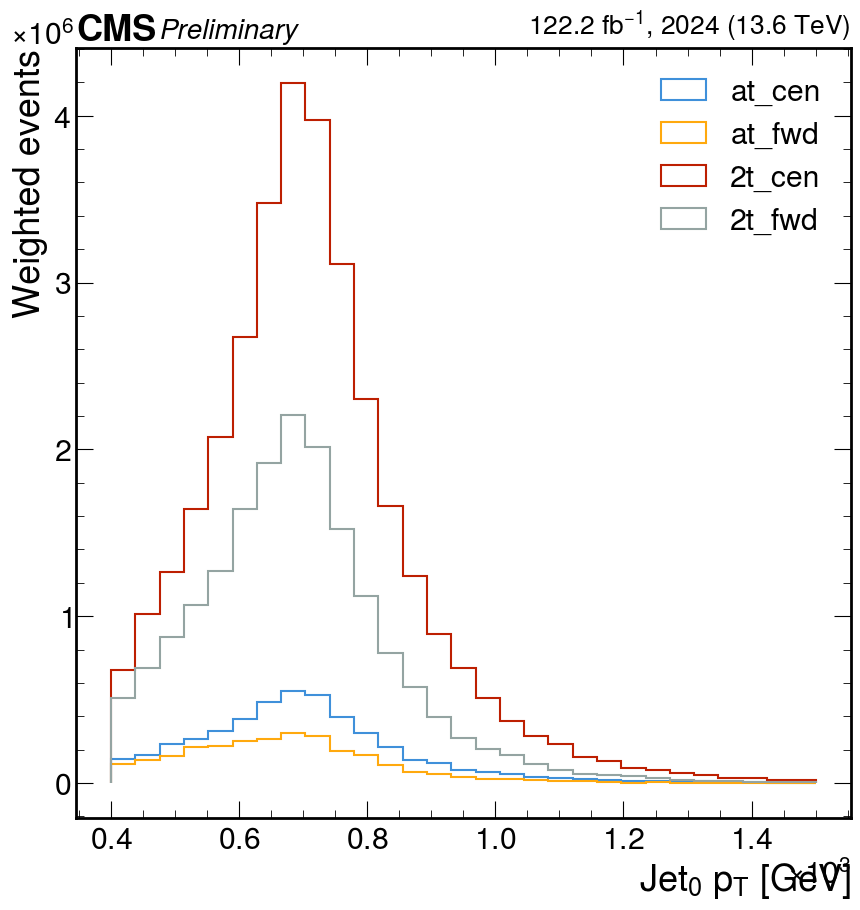

In [22]:
# ── 1D: jet0_pt by category ───────────────────────────────────────────────────
fig, ax = plt.subplots()

bins = np.linspace(400, 1500, 30)
for label, mask in masks.items():
    ax.hist(arrays["jet0_pt"][mask], bins=bins, weights=arrays["weight"][mask],
            histtype="step", linewidth=1.5, label=label)

ax.legend()
hep_plot.quick_label(xlabel=r"Jet$_0\ p_T$ [GeV]", ylabel="Weighted events",
                     data=True, ax=ax)
hep_plot.show("jet0_pt_by_cat")

Saved -> outputs/plots/dy_cen_fwd_2024.pdf
Saved -> outputs/plots/dy_cen_fwd_2024.png


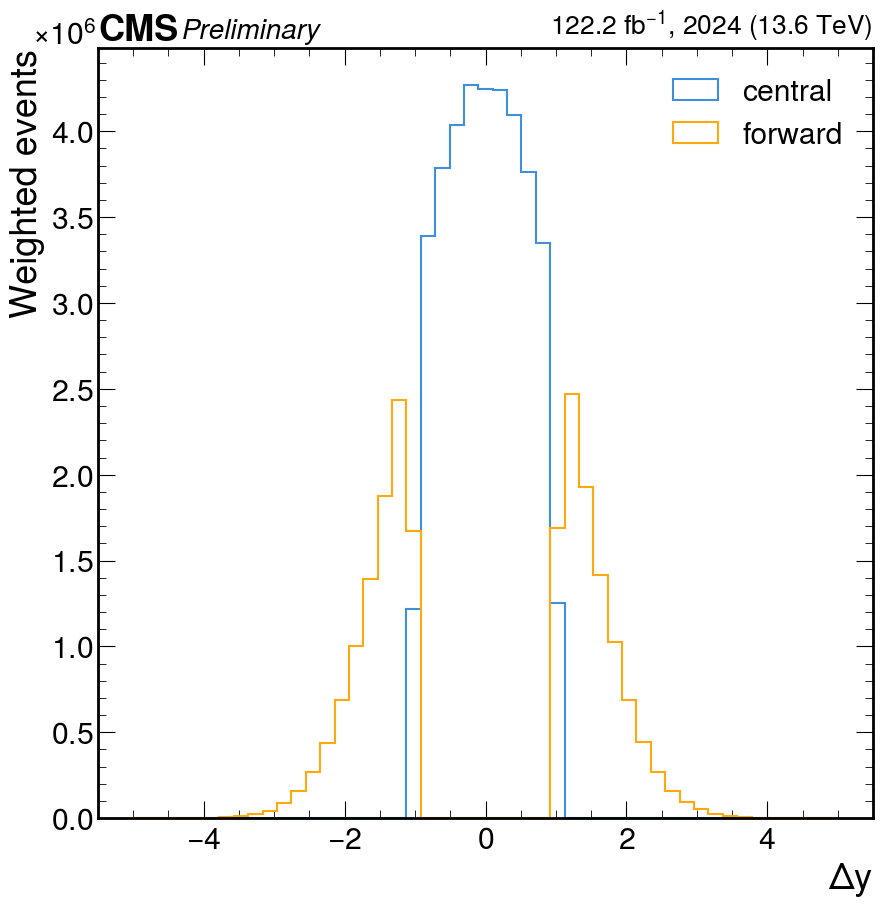

In [23]:
# 1D: dy — central vs forward
mask_cen = (arrays["anacat"] == 0) | (arrays["anacat"] == 2)
mask_fwd = (arrays["anacat"] == 1) | (arrays["anacat"] == 3)

fig, ax = plt.subplots()
bins = np.linspace(-5, 5, 50)
ax.hist(arrays["dy"][mask_cen], bins=bins, weights=arrays["weight"][mask_cen],
        histtype="step", linewidth=1.5, label="central")
ax.hist(arrays["dy"][mask_fwd], bins=bins, weights=arrays["weight"][mask_fwd],
        histtype="step", linewidth=1.5, label="forward")
ax.legend()
hep_plot.quick_label(xlabel=r"$\Delta y$", ylabel="Weighted events", data=True, ax=ax)
hep_plot.show("dy_cen_fwd")

Saved -> outputs/plots/chi_cen_fwd_2024.pdf
Saved -> outputs/plots/chi_cen_fwd_2024.png


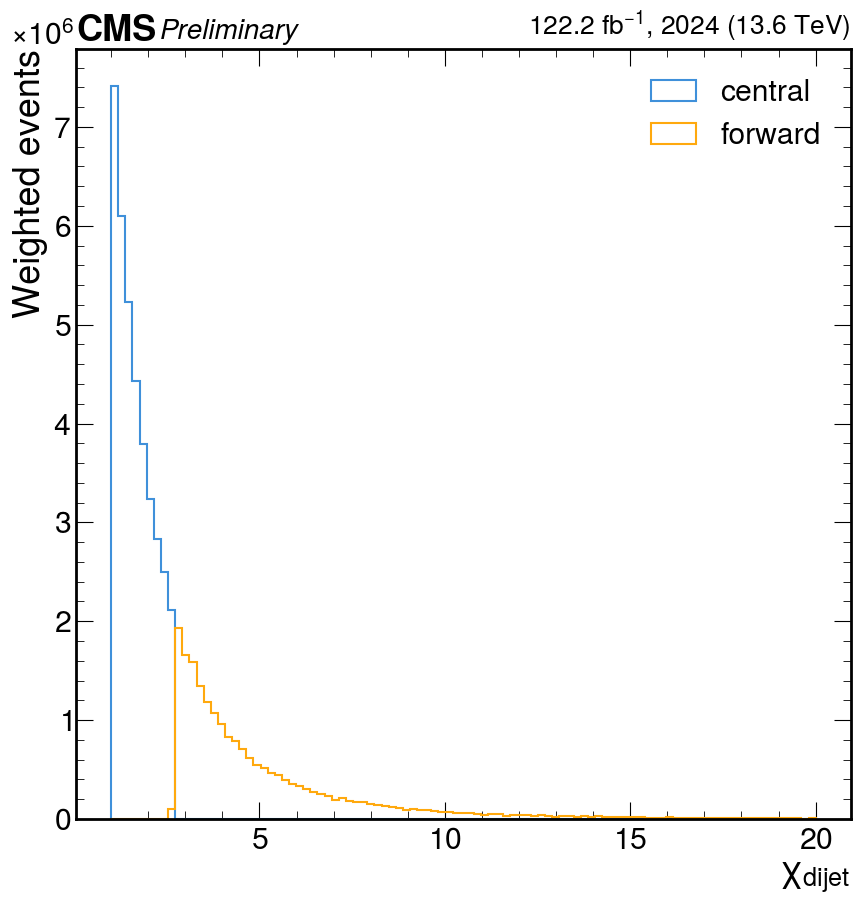

In [30]:
# 1D: chi — central vs forward
fig, ax = plt.subplots()
bins = np.linspace(1, 20, 100)
ax.hist(arrays["chi"][mask_cen], bins=bins, weights=arrays["weight"][mask_cen],
        histtype="step", linewidth=1.5, label="central")
ax.hist(arrays["chi"][mask_fwd], bins=bins, weights=arrays["weight"][mask_fwd],
        histtype="step", linewidth=1.5, label="forward")
ax.legend()
hep_plot.quick_label(xlabel=r"$\chi_{\mathrm{dijet}}$", ylabel="Weighted events", data=True, ax=ax)
hep_plot.show("chi_cen_fwd")

Saved -> outputs/plots/jet_msd_overlay_2024.pdf
Saved -> outputs/plots/jet_msd_overlay_2024.png


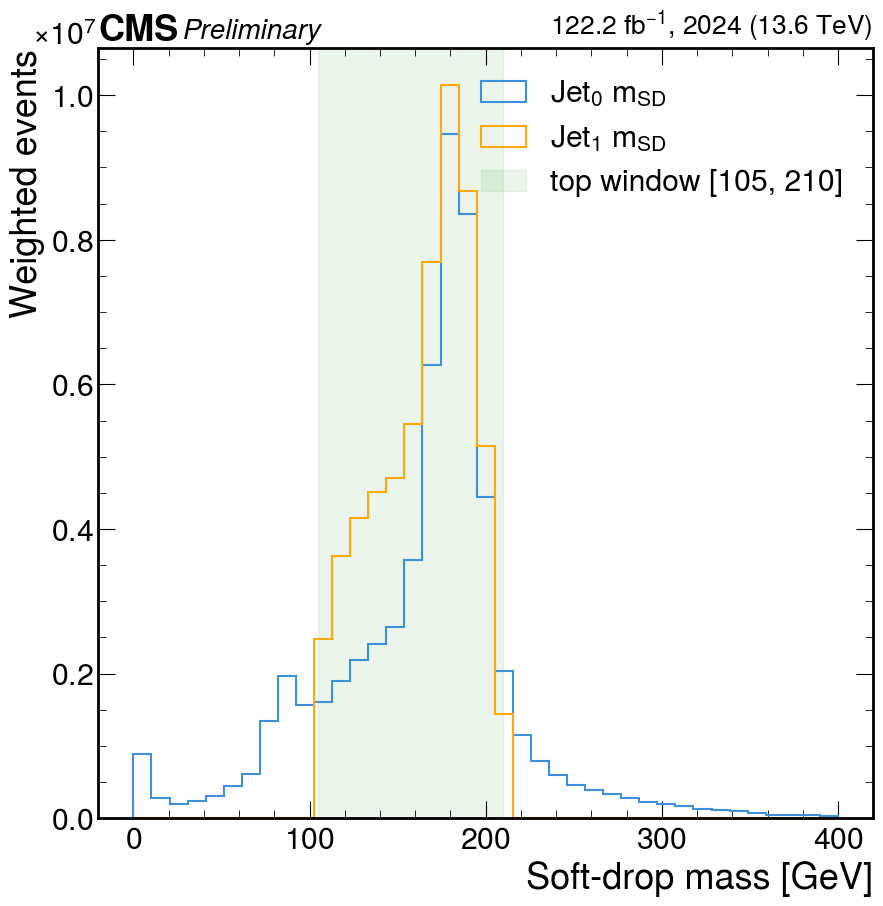

In [25]:
# ── 1D: jet0_msd and jet1_msd overlay ────────────────────────────────────────
fig, ax = plt.subplots()

bins = np.linspace(0, 400, 40)
w = arrays["weight"][mask_any]
ax.hist(arrays["jet0_msd"][mask_any], bins=bins, weights=w,
        histtype="step", linewidth=1.5, label=r"Jet$_0\ m_{SD}$")
ax.hist(arrays["jet1_msd"][mask_any], bins=bins, weights=w,
        histtype="step", linewidth=1.5, label=r"Jet$_1\ m_{SD}$")
ax.axvspan(105, 210, alpha=0.08, color="green", label="top window [105, 210]")

ax.legend()
hep_plot.quick_label(xlabel=r"Soft-drop mass [GeV]", ylabel="Weighted events",
                     data=True, ax=ax)
hep_plot.show("jet_msd_overlay")

Saved -> outputs/plots/jet0_pt_vs_mttbar_2tag_2024.pdf
Saved -> outputs/plots/jet0_pt_vs_mttbar_2tag_2024.png


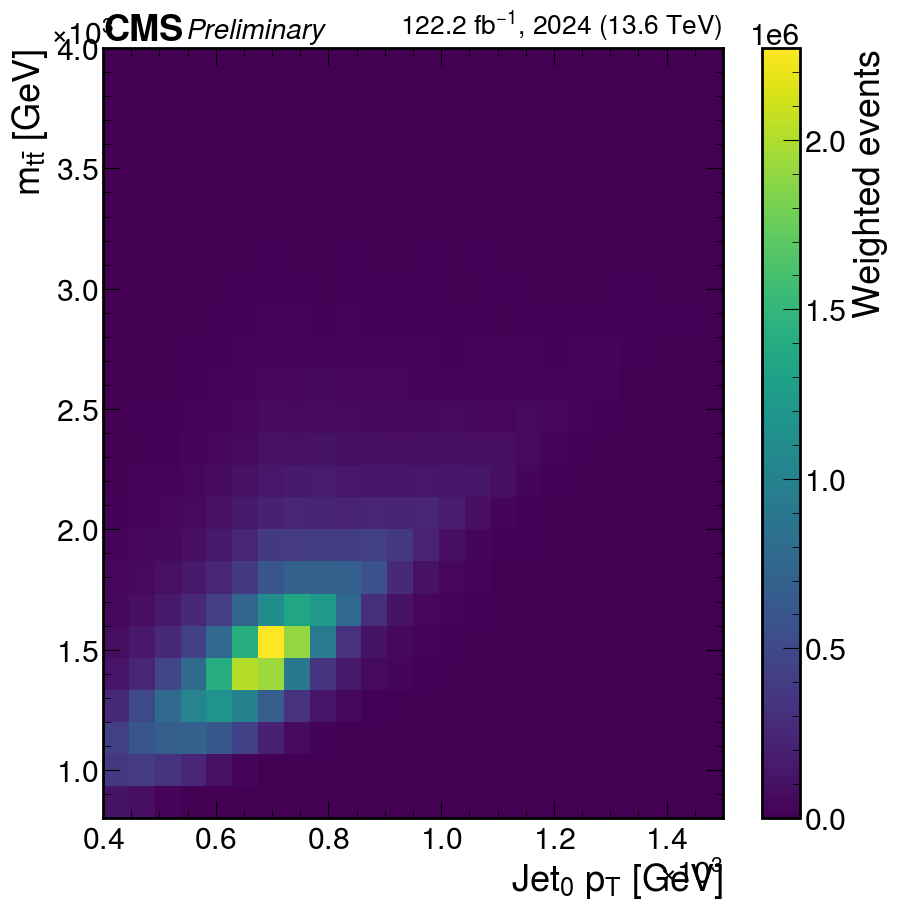

In [28]:
# ── 2D: jet0_pt vs ttbarmass (signal region) ──────────────────────────────────
fig, ax = plt.subplots()

w = arrays["weight"][mask_2tag]
_, _, _, img = ax.hist2d(
    arrays["jet0_pt"][mask_2tag],
    arrays["ttbarmass"][mask_2tag],
    bins=[np.linspace(400, 1500, 25), np.linspace(800, 4000, 25)],
    weights=w,
    cmap="viridis",
)
fig.colorbar(img, ax=ax, label="Weighted events")

hep_plot.quick_label(xlabel=r"Jet$_0\ p_T$ [GeV]", ylabel=r"$m_{t\bar{t}}$ [GeV]",
                     data=True, ax=ax)
hep_plot.show("jet0_pt_vs_mttbar_2tag")

Saved -> outputs/plots/jet_msd_2d_2tag_2024.pdf
Saved -> outputs/plots/jet_msd_2d_2tag_2024.png


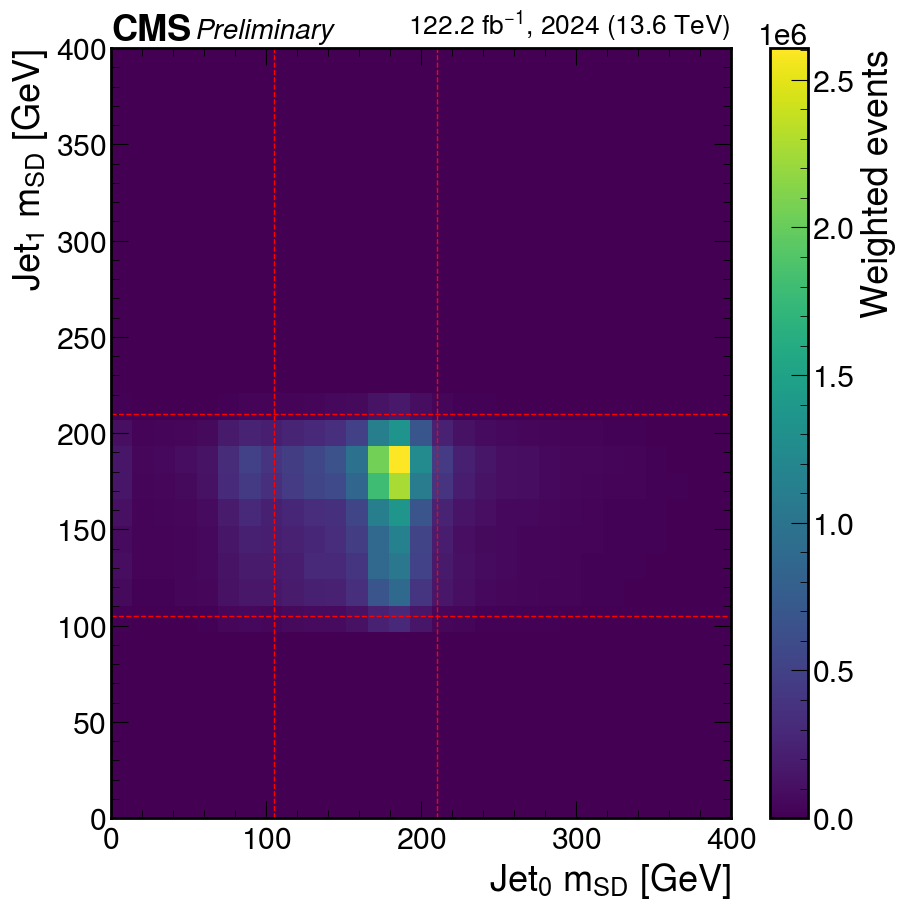

In [27]:
# ── 2D: jet0_msd vs jet1_msd (signal region) ──────────────────────────────────
fig, ax = plt.subplots()

bins_msd = np.linspace(0, 400, 30)
w = arrays["weight"][mask_2tag]
_, _, _, img = ax.hist2d(
    arrays["jet0_msd"][mask_2tag],
    arrays["jet1_msd"][mask_2tag],
    bins=[bins_msd, bins_msd],
    weights=w,
    cmap="viridis",
)
fig.colorbar(img, ax=ax, label="Weighted events")

for val in [105, 210]:
    ax.axvline(val, color="red", linestyle="--", linewidth=1)
    ax.axhline(val, color="red", linestyle="--", linewidth=1)

hep_plot.quick_label(xlabel=r"Jet$_0\ m_{SD}$ [GeV]", ylabel=r"Jet$_1\ m_{SD}$ [GeV]",
                     data=True, ax=ax)
hep_plot.show("jet_msd_2d_2tag")